In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
from classy import Class

In [3]:
from fkpwin.sphere import qell_s_spherical_vectorized, qell_k_spherical
from fkpwin.fkpwin import WindowMatrix

# A ball in the Sky

In [4]:
radius = 1000.

Suppose we measure the 3D power spectrum of fluctuations inside the ball with an FFT-based estimator giving the following $k$-bins: 

In [5]:
box, pmesh = 2.*radius, 8
kf, knq = 2*np.pi/box, np.pi * 2**pmesh/box
kedges = np.arange(kf, knq-1e-16, kf)
kcen = kedges[:-1] + kf/2.

### Power spectrum window matrix
The power spectrum multipoles of a density field observed in a region $V$ are
\begin{equation}
P_\ell^{conv}(k) = \int dp \ p^2 \ \sum_{\ell'} W_{\ell \ell'}(k,p) P_{\ell'}(p) \ , 
\end{equation}
where
\begin{equation}
W_{\ell, \ell'}(k, p) = \frac{2}{\pi} (2\ell+1) (-i)^\ell i^{\ell'} \int ds \ s^2 j_\ell(ks) j_{\ell'}(p s) \sum_L \left(\begin{matrix}
\ell & L & \ell'\\
0 & 0 & 0
\end{matrix}\right)^2 Q_L(s) \ .
\end{equation}
Here $Q_L(s)$ are the correlation function multipoles of (a uniform field filling) the region $V$. 

Refer to App. A of 2208.05930 for derivations of these equations.

### $W_{\ell, \ell'}(k, p)$

In [6]:
ells = [0, 2]

Instantiate main class where we can specify $s = $ `s` and $k = p = $ `k`

In [7]:
win = WindowMatrix(s=None, k=None, kedges=kedges, ells=ells, NFFT=1024*16) 

Here we use the default ones

In [8]:
s, k = win.s, win.k

$Q_\ell(s)$: all nonzero in this example, as we use assume endpoint LOS. 

In [9]:
qs = np.array([qell_s_spherical_vectorized(ell, s, radius) for ell in ells]) 
qs /= qs[0,0]

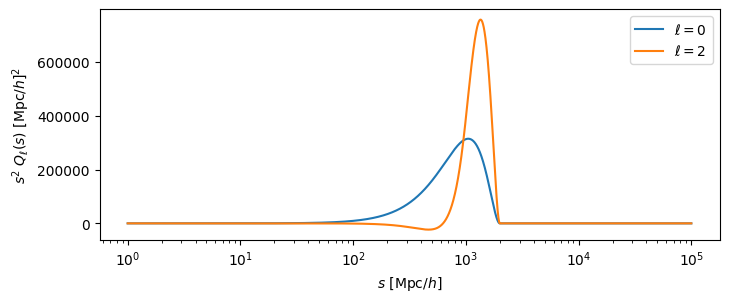

In [10]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells): 
    plt.plot(s, s**2 * qs[i], 'C%s' % i, label=r'$\ell=%s$' % ell)
plt.ylabel(r'$s^2 \ Q_\ell(s) \ [{\rm Mpc}/h]^2$')
plt.xlabel(r'$s \ [{\rm Mpc}/h]$')
plt.xscale('log')
plt.legend()

$Q_\ell(k)$: alternatively, we can provide directly power spectrum multipoles related as
\begin{equation}
Q_\ell(s) = i^{\ell} \int dk \ k^2 \ j_\ell(ks) Q_\ell(k)
\end{equation}

In [11]:
k_ = np.geomspace(1e-4, 1., 1024)
q0k = qell_k_spherical(0, k_, radius) # we do it only for ell = 0 otherwise quite slow

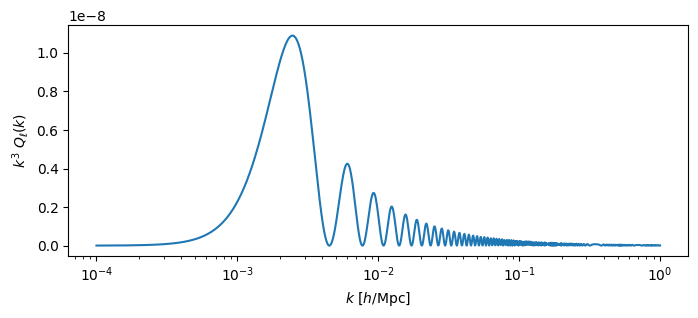

In [12]:
plt.figure(figsize=(8,3))
plt.plot(k_, k_**3 * q0k, 'C0', label=r'fm $\ell=0')
plt.ylabel(r'$k^3 \ Q_\ell(k)$')
plt.xlabel(r'$k \ [h/{\rm Mpc}]$')
plt.xscale('log')

In [13]:
win_ = WindowMatrix(s, k, ells=[0])
q0s = win_.qs_from_qk([q0k], k=k_)[0]

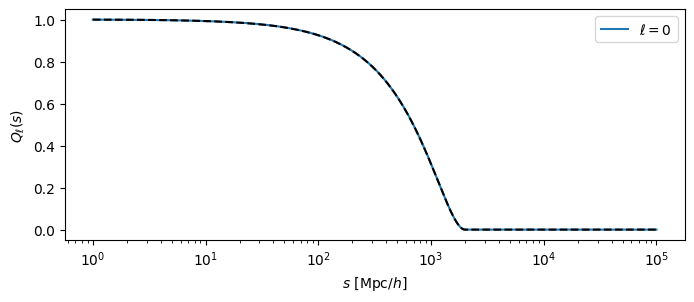

In [14]:
plt.figure(figsize=(8,3))
plt.plot(s, qs[0], 'C0', label=r'$\ell=0$')
plt.plot(s, q0s, '--k')
plt.ylabel(r'$Q_\ell(s)$')
plt.xlabel(r'$s \ [{\rm Mpc}/h]$')
plt.xscale('log')
plt.legend()

Specify $Q_\ell(s)$ and $Q_\ell(k)$ to the class `WindowMatrix`

In [15]:
win.set(q0k, k=k_, qs=qs, s=s)

$W_{\ell, \ell'}(k, p)$, finally

In [16]:
%%time 
wmat = win.get()

CPU times: user 1min 13s, sys: 2.43 s, total: 1min 15s
Wall time: 1min 21s


### $P_\ell(k)$

In [17]:
M = Class()
M.set({'output':'mPk', 'z_max_pk': 0., 'P_k_max_h/Mpc': 1.0})
M.compute()
pk_lin = np.array([M.pk(ki * M.h(), 0.) for ki in k]) * M.h()**3

Kaiser

In [18]:
mu = {
    0: {0: 1., 2: 0., 4: 0.},
    2: {0: 1. / 3., 2: 2. / 3., 4: 0.},
    4: {0: 1. / 5., 2: 4. / 7., 4: 8. / 35.},
}

In [19]:
b1, f1 = 1., M.scale_independent_growth_factor_f(0.)

In [20]:
beta_l = np.array([b1**2 * mu[0][l] + 2*b1*f1*mu[2][l] + f1**2*mu[4][l] for l in ells])
pk = np.einsum('l,k->lk', beta_l, pk_lin)

In [21]:
wpk = np.einsum("lmkp,mp->lkp", wmat, pk)
pk_c = np.trapz(wpk, x=win.k, axis=-1)

/Users/pierre/.pyenv/versions/3.11.9/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pierre/.pyenv/versions/3.11.9/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


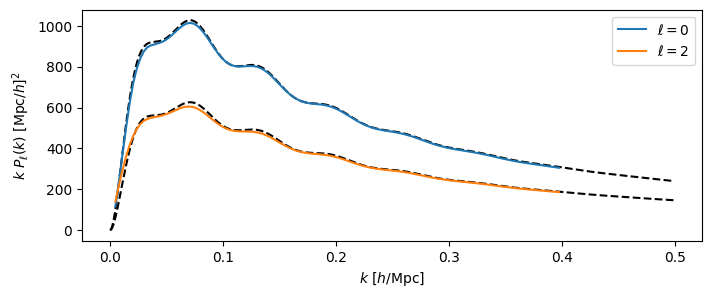

In [22]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells): 
    plt.plot(k, k*pk[i], '--k')
    plt.plot(kcen, kcen * pk_c[i], 'C%s' % i, label=r'$\ell=%s$' % ell)
plt.ylabel(r'$k \ P_\ell(k) \ [{\rm Mpc}/h]^2$')
plt.xlabel(r'$k \ [h/{\rm Mpc}]$')
plt.legend()